# Introduction to _NatureDataCube_

This tutorial was made for the Veluwe Research Community Meeting on June 30th, 2026.

## What is _NatureDataCube_?

_NatureDataCube_ is a tool to facilitate access to data for nature areas in the Netherlands. It is under active development under the context of LTER-LIFE.

In [32]:
# Load packages
library(NatureDataCubeR)
library(rstac)
library(sf)
library(terra)
library(dplyr)
library(ggplot2)

# Load token
ndc_token <- Sys.getenv("NDC_TOKEN")

# Define paths to boundaries
path_nl <- system.file("extdata/nl.gpkg", package = "NatureDataCubeR")
path_veluwe <- system.file("extdata/veluwe.gpkg", package = "NatureDataCubeR")

# Define time period
tperiod <- ndc_trange(c("2019-01-01", "2025-12-31"))

## Boundaries

In [2]:
nl <- ndc_roi(path_nl)
veluwe <- ndc_roi(path_veluwe)

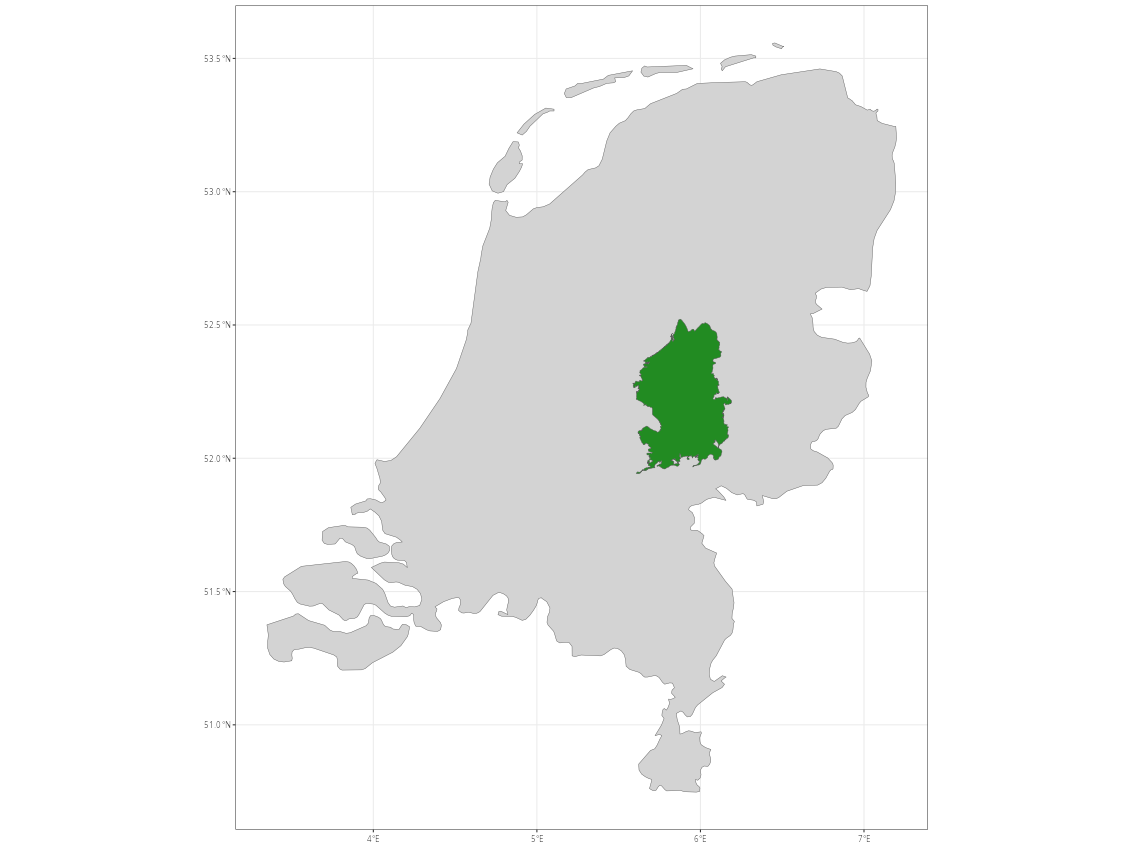

In [3]:
ggplot() +
  geom_sf(data = st_geometry(nl), fill = "lightgray") +
  geom_sf(data = st_geometry(veluwe), fill = "forestgreen") +
  coord_sf(datum = st_crs(4326)) +
  theme_bw()

In [4]:
lter <- ndc_get(collection = ndc_datasets()[4],
                roi = veluwe,
                mode = "sf") |>
  filter(substr(name, 1, 4) == "Nest")
print(lter)

Simple feature collection with 3 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.867511 ymax: 52.04628
Geodetic CRS:  WGS 84
# A tibble: 3 × 5
  datetime             name              ndc_id  `proj:epsg`                                geometry
* <chr>                <chr>             <chr>         <int>                      <MULTIPOLYGON [°]>
1 2026-05-04T23:29:36Z Nestkast Veluwe   1264472       28992 (((5.837216 52.04044, 5.837859 52.0416…
2 2026-05-04T23:29:36Z Nestkast Boslust  1264470       28992 (((5.836293 52.02099, 5.836806 52.0234…
3 2026-05-04T23:29:36Z Nestkast Bennekom 1264469       28992 (((5.689241 51.9972, 5.689912 52.00078…


In [5]:
lter_ids <- unique(lter$ndc_id)

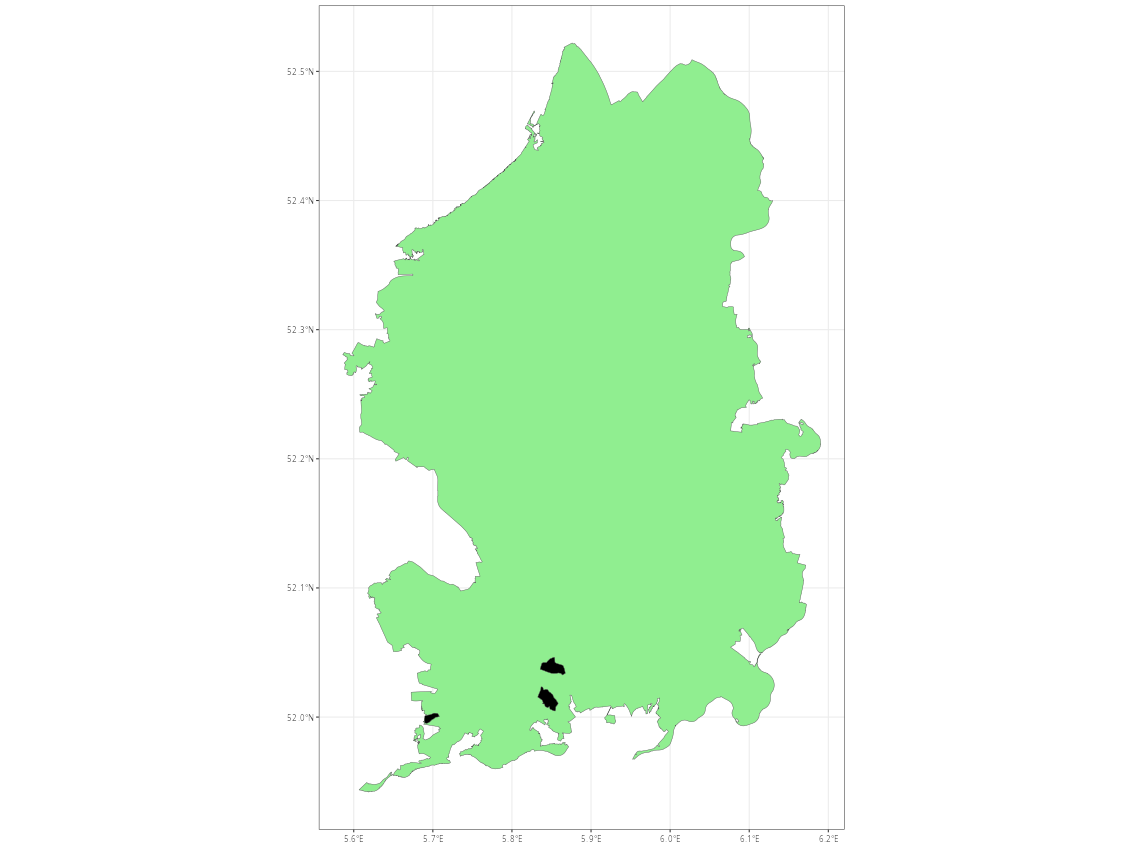

In [6]:
ggplot() +
  geom_sf(data = st_geometry(veluwe), fill = "lightgreen") +
  geom_sf(data = st_geometry(lter), fill = "black") +
  coord_sf(datum = st_crs(4326)) +
  theme_bw()

## Focus dataset

In [7]:
nestboxes <- read.csv("~/Downloads/first_nests_HV.csv") |>
  filter(year >= 2019 & year <= 2025) |>
  st_as_sf(coords = c("lon_dd", "lat_dd"), crs = 4326)
print(nestboxes)

Simple feature collection with 2423 features and 6 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 5.835793 ymin: 52.0325 xmax: 5.866197 ymax: 52.04632
Geodetic CRS:  WGS 84
First 10 features:
   year nestbox_id         species   lay_date clutch_size ld_doy                  geometry
1  2019  HV.0001.0       great tit 2019-04-11           8    101 POINT (5.854121 52.04621)
2  2020  HV.0001.0       great tit 2020-04-18          10    109 POINT (5.854121 52.04621)
3  2021  HV.0001.0       great tit 2021-04-26          10    116 POINT (5.854121 52.04621)
4  2022  HV.0001.0       great tit 2022-04-15           8    105 POINT (5.854121 52.04621)
5  2023  HV.0001.0       great tit 2023-04-18           7    108 POINT (5.854121 52.04621)
6  2024  HV.0001.0       great tit 2024-04-09          11    100 POINT (5.854121 52.04621)
7  2025  HV.0001.0       great tit 2025-04-11          11    101 POINT (5.854121 52.04621)
8  2019  HV.0002.0       great tit 2019-04-17           7   

In [8]:
nestboxes |>
  as_tibble() |>
  summarize(clutch_size = mean(clutch_size, na.rm = TRUE),
            .by = c(species, year))

# A tibble: 31 × 3
   species          year clutch_size
   <chr>           <int>       <dbl>
 1 great tit        2019        7.85
 2 great tit        2020        8.81
 3 great tit        2021        8.05
 4 great tit        2022        8.79
 5 great tit        2023        7.95
 6 great tit        2024        9.37
 7 great tit        2025        8.87
 8 pied flycatcher  2021        6.27
 9 blue tit         2022       10.1 
10 pied flycatcher  2020        6.74
# ℹ 21 more rows
# ℹ Use `print(n = ...)` to see more rows

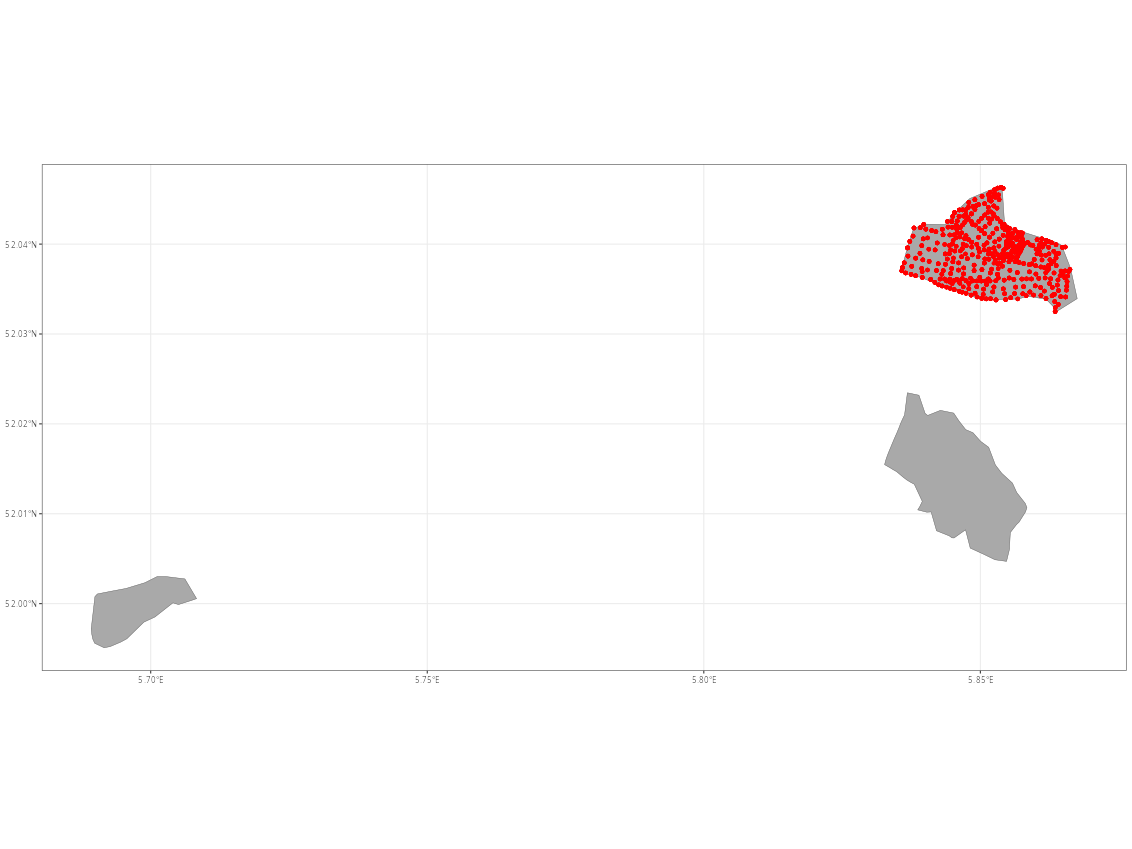

In [15]:
ggplot() +
  geom_sf(data = st_geometry(lter), fill = "darkgrey") +
  geom_sf(data = st_geometry(nestboxes), color = "red") +
  coord_sf(datum = st_crs(4326)) +
  theme_bw()

## NDVI

In [23]:
ndvi <- ndc_get(collection = "ndvi-lter",
                roi = veluwe,
                trange = tperiod,
                mode = "sf",
                limit = 10000,
                token = ndc_token)
print(ndvi)

Simple feature collection with 5810 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 5,810 × 10
   datetime        ndc_id ndvi_count ndvi_mean ndvi_std observation_date parcel_collection_id source
   <chr>           <chr>       <dbl>     <dbl>    <dbl> <chr>            <chr>                <chr> 
 1 2025-12-30T00:… 12644…         68     0.794   0.0302 2025-12-30T00:0… lter                 LTER  
 2 2025-12-30T00:… 12644…         36     0.776   0.0331 2025-12-30T00:0… lter                 LTER  
 3 2025-12-30T00:… 12644…         34     0.761   0.0296 2025-12-30T00:0… lter                 LTER  
 4 2025-12-30T00:… 12644…         33     0.741   0.0598 2025-12-30T00:0… lter                 LTER  
 5 2025-12-30T00:… 12644…         29     0.622   0.136  2025-12-30T00:0… lter                 LTER  
 6 2025-12-30T00:… 12644…         33     0.752   0.0346 2025-12-30T00

In [24]:
st_drop_geometry(ndvi)

# A tibble: 5,810 × 9
   datetime        ndc_id ndvi_count ndvi_mean ndvi_std observation_date parcel_collection_id source
 * <chr>           <chr>       <dbl>     <dbl>    <dbl> <chr>            <chr>                <chr> 
 1 2025-12-30T00:… 12644…         68     0.794   0.0302 2025-12-30T00:0… lter                 LTER  
 2 2025-12-30T00:… 12644…         36     0.776   0.0331 2025-12-30T00:0… lter                 LTER  
 3 2025-12-30T00:… 12644…         34     0.761   0.0296 2025-12-30T00:0… lter                 LTER  
 4 2025-12-30T00:… 12644…         33     0.741   0.0598 2025-12-30T00:0… lter                 LTER  
 5 2025-12-30T00:… 12644…         29     0.622   0.136  2025-12-30T00:0… lter                 LTER  
 6 2025-12-30T00:… 12644…         33     0.752   0.0346 2025-12-30T00:0… lter                 LTER  
 7 2025-12-30T00:… 12644…         31     0.710   0.0911 2025-12-30T00:0… lter                 LTER  
 8 2025-12-30T00:… 12644…     115341     0.755   0.0886 2025-12-30T00

### Temporally subset data

In [25]:
ndvi <- ndvi |>
  mutate(year = as.integer(substr(observation_date, 1, 4)),
         month = as.integer(substr(observation_date, 6, 7))) |>
  filter(year >= 2019 & year <= 2025,
         month >= 3 & month <= 5)
print(ndvi)

Simple feature collection with 2148 features and 11 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 2,148 × 12
   datetime        ndc_id ndvi_count ndvi_mean ndvi_std observation_date parcel_collection_id source
 * <chr>           <chr>       <dbl>     <dbl>    <dbl> <chr>            <chr>                <chr> 
 1 2025-05-26T00:… 12644…         10     0.62    0.0101 2025-05-26T00:0… lter                 LTER  
 2 2025-05-26T00:… 12644…         17     0.615   0.0618 2025-05-26T00:0… lter                 LTER  
 3 2025-05-26T00:… 12644…      57047     0.697   0.0713 2025-05-26T00:0… lter                 LTER  
 4 2025-05-19T00:… 12644…         24     0.721   0.132  2025-05-19T00:0… lter                 LTER  
 5 2025-05-19T00:… 12644…         34     0.692   0.122  2025-05-19T00:0… lter                 LTER  
 6 2025-05-19T00:… 12644…         29     0.664   0.120  2025-05-19T0

In [26]:
ndvi_mean <- ndvi |>
  summarize(NDVI_mean = mean(ndvi_mean, na.rm = TRUE),
            NDVI_sd = sd(ndvi_mean, na.rm = TRUE),
            NDVI_min = min(ndvi_mean, na.rm = TRUE),
            NDVI_max = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = ndc_id)
print(ndvi_mean)

Simple feature collection with 28 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 28 × 6
   ndc_id  NDVI_mean NDVI_sd NDVI_min NDVI_max                                              geometry
   <chr>       <dbl>   <dbl>    <dbl>    <dbl>                                         <POLYGON [°]>
 1 1264490     0.670  0.0669    0.560    0.831 ((5.852229 52.36794, 5.852343 52.36793, 5.852456 52.…
 2 1264485     0.696  0.0568    0.568    0.796 ((5.856979 52.36444, 5.857092 52.36443, 5.857206 52.…
 3 1264474     0.688  0.0457    0.5      0.791 ((5.706391 52.16479, 5.736783 52.14783, 5.770781 52.…
 4 1264498     0.641  0.0450    0.538    0.801 ((5.897389 52.37651, 5.897503 52.3765, 5.897616 52.3…
 5 1264497     0.645  0.0400    0.544    0.738 ((5.895003 52.3746, 5.895116 52.37459, 5.89523 52.37…
 6 1264496     0.634  0.0406    0.489    0.717 ((5.891448 52.37194, 5.891562 52.

### Yearly aggregate stats

In [27]:
ndvi |>
  filter(ndc_id %in% lter_ids) |>
  summarize(ndvi_ymean = mean(ndvi_mean, na.rm = TRUE),
            ndvi_ycov = sd(ndvi_mean, na.rm = TRUE) / ndvi_ymean,
            ndvi_ymin = min(ndvi_mean, na.rm = TRUE),
            ndvi_ymax = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = c(ndc_id, year))

Simple feature collection with 21 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.867511 ymax: 52.04628
Geodetic CRS:  WGS 84
# A tibble: 21 × 7
   ndc_id   year ndvi_ymean ndvi_ycov ndvi_ymin ndvi_ymax                                   geometry
   <chr>   <int>      <dbl>     <dbl>     <dbl>     <dbl>                              <POLYGON [°]>
 1 1264472  2025      0.650     0.169     0.522     0.818 ((5.836787 52.03956, 5.835693 52.03705, 5…
 2 1264470  2025      0.654     0.181     0.518     0.818 ((5.835915 52.02051, 5.835588 52.02006, 5…
 3 1264469  2025      0.683     0.249     0.499     0.901 ((5.689336 51.99663, 5.689526 51.99607, 5…
 4 1264472  2024      0.698     0.125     0.593     0.799 ((5.836787 52.03956, 5.835693 52.03705, 5…
 5 1264470  2024      0.714     0.115     0.615     0.810 ((5.835915 52.02051, 5.835588 52.02006, 5…
 6 1264469  2024      0.748     0.162     0.597     0.876 ((5.689336 51.99663, 5

## Soil

In [29]:
ndc_datasets()

[1] "ndvi-lter"              "ndvi-snl"               "ndc-geoserver-rasters" 
[4] "lter"                   "snl"                    "groenmonitor-geoserver"

In [ ]:
ndc_get(collection = "ndc-geoserver-rasters",
        roi = veluwe,
        trange = tperiod,
        mode = "items",
        limit = 10000,
        token = ndc_token) |>
  items_filter("lgn" %in% properties$keywords)

###Items
- matched feature(s): 7
- features (1 item(s) / 6 not fetched):
  - ndc-geoserver-rasters-lgn2024_05m
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

In [ ]:
ndc_get(collection = "ndc-geoserver-rasters",
        roi = veluwe,
        trange = tperiod,
        mode = "sf",
        token = ndc_token)

Simple feature collection with 7 features and 13 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 3.31 ymin: 50.75 xmax: 7.23 ymax: 53.55
Geodetic CRS:  WGS 84
# A tibble: 7 × 14
  datetime             description        end_datetime `geoserver:layer_name` geoserver:qualified_…¹
  <chr>                <chr>              <chr>        <chr>                  <chr>                 
1 2025-01-01T00:00:00Z Modelled total ni… 2025-01-01T… depo_NTOT_2025         ndc:depo_NTOT_2025    
2 2025-01-01T00:00:00Z Modelled NOx conc… 2025-01-01T… conc_NOx_2025          ndc:conc_NOx_2025     
3 2025-01-01T00:00:00Z Modelled NH3 conc… 2025-01-01T… conc_NH3_2025          ndc:conc_NH3_2025     
4 2024-01-01T00:00:00Z Land use classifi… 2024-01-01T… LGN2024_05m            ndc:LGN2024_05m       
5 2024-01-01T00:00:00Z Modelled total ni… 2024-01-01T… depo_NTOT_2024         ndc:depo_NTOT_2024    
6 2024-01-01T00:00:00Z Modelled NOx conc… 2024-01-01T… conc_NOx_2024          ndc:conc_NOx_202